Import Libraries & Load Data

In [2]:
# Import Python packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
companies = pd.read_csv("Unicorn_Companies.csv")

# Verify initial load
print("Dataset Shape:", companies.shape)
companies.head(10)

Dataset Shape: (300, 10)


,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Fintech,San Francisco,India,Europe,2007,$790M,"Sequoia Capital, Tiger Global, Accel"
1,SpaceX,$100B,12/1/12,E-commerce & direct-to-consumer,Berlin,China,North America,2008,$187M,"Sequoia Capital, Tiger Global, Accel"
2,SHEIN,$100B,7/3/18,Mobile & telecommunications,Bengaluru,Germany,Asia,2004,$652M,"Sequoia Capital, Tiger Global, Accel"
3,Stripe,$95B,1/23/14,E-commerce & direct-to-consumer,Bengaluru,China,Asia,2005,$500M,"Sequoia Capital, Tiger Global, Accel"
4,Klarna,$46B,12/12/11,Mobile & telecommunications,San Francisco,United States,North America,1996,$687M,"Sequoia Capital, Tiger Global, Accel"
5,Company_6,$21B,04/10/10,Other,Shenzhen,Germany,Europe,2019,$145M,"Sequoia Capital, Tiger Global, Accel"
6,Company_7,$39B,04/30/10,Other,Berlin,United Kingdom,North America,2020,$771M,"Sequoia Capital, Tiger Global, Accel"
7,Company_8,$19B,05/19/10,Other,Berlin,China,Europe,2003,$562M,"Sequoia Capital, Tiger Global, Accel"
8,Company_9,$23B,06/08/10,"Supply chain, logistics, & delivery",New York,United States,Asia,2011,$691M,"Sequoia Capital, Tiger Global, Accel"
9,Company_10,$11B,06/28/10,E-commerce & direct-to-consumer,Bengaluru,India,Europe,2020,$409M,"Sequoia Capital, Tiger Global, Accel"


Data Exploration & Deduplication

In [3]:
# Check shape after dropping duplicates to verify uniqueness
print("Shape after dropping duplicates:", companies.drop_duplicates().shape)

# Check column data types
print("\n--- DATA TYPES ---")
print(companies.dtypes)

Shape after dropping duplicates: (300, 10)

--- DATA TYPES ---
Company               str
Valuation             str
Date Joined           str
Industry              str
City                  str
Country/Region        str
Continent             str
Year Founded        int64
Funding               str
Select Investors      str
dtype: object


Sorting Data by Founding Year & Value Counting

--- NEWEST COMPANIES (FOUNDED 2021+) ---


,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
24,Company_25,$33B,04/22/11,"Supply chain, logistics, & delivery",Beijing,United Kingdom,North America,2021,$265M,"Sequoia Capital, Tiger Global, Accel"
249,Company_250,$19B,07/12/23,Consumer & retail,Bengaluru,India,North America,2021,$768M,"Sequoia Capital, Tiger Global, Accel"
47,Company_48,$9B,07/21/12,Data management & analytics,New York,United States,North America,2021,$417M,"Sequoia Capital, Tiger Global, Accel"
66,Company_67,$4B,08/02/13,Other,Shenzhen,India,North America,2021,$636M,"Sequoia Capital, Tiger Global, Accel"
60,Company_61,$36B,04/05/13,E-commerce & direct-to-consumer,Berlin,China,North America,2021,$226M,"Sequoia Capital, Tiger Global, Accel"
169,Company_170,$42B,03/08/19,Artificial intelligence,Shenzhen,India,Europe,2021,$494M,"Sequoia Capital, Tiger Global, Accel"
176,Company_177,$20B,07/25/19,Other,London,Germany,Asia,2021,$877M,"Sequoia Capital, Tiger Global, Accel"
226,Company_227,$32B,04/12/22,Consumer & retail,Beijing,India,Asia,2021,$316M,"Sequoia Capital, Tiger Global, Accel"
219,Company_220,$32B,11/24/21,"Supply chain, logistics, & delivery",San Francisco,United Kingdom,North America,2021,$589M,"Sequoia Capital, Tiger Global, Accel"
210,Company_211,$37B,05/29/21,Consumer & retail,Beijing,United States,Europe,2021,$134M,"Sequoia Capital, Tiger Global, Accel"



--- NUMBER OF COMPANIES FOUNDED PER YEAR ---


Year Founded
2021    17
2007    16
1997    16
2009    16
2011    15
1996    14
2005    13
2018    13
2000    13
2008    12
Name: count, dtype: int64

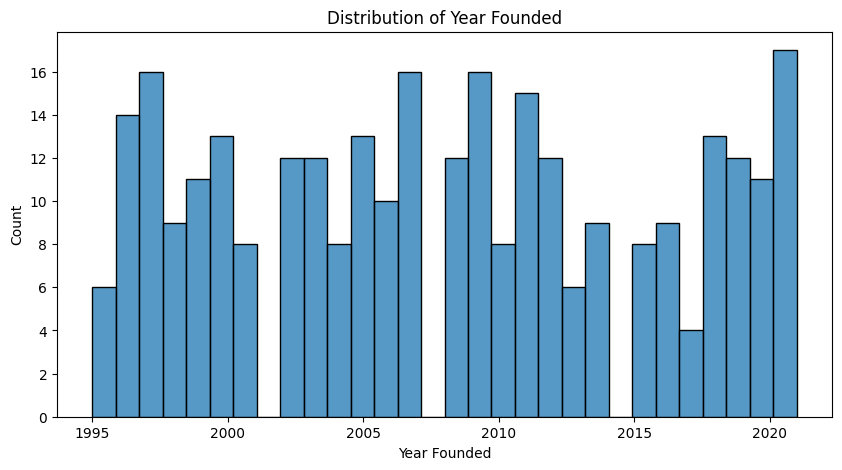

In [6]:
# Sort by Year Founded descending to view newest companies
print("--- NEWEST COMPANIES (FOUNDED 2021+) ---")
display(companies.sort_values(by="Year Founded", ascending=False).head(10))

# Count occurrences of each founding year
print("\n--- NUMBER OF COMPANIES FOUNDED PER YEAR ---")
display(companies["Year Founded"].value_counts().sort_values(ascending=False).head(10))

# Plot histogram of founding years
plt.figure(figsize=(10, 5))
sns.histplot(data=companies, x='Year Founded', bins=30)
plt.title('Distribution of Year Founded')
plt.xlabel('Year Founded')
plt.ylabel('Count')
plt.show()

Datetime Conversion & Feature Engineering

In [7]:
# Convert 'Date Joined' string column to datetime type
companies["Date Joined"] = pd.to_datetime(companies["Date Joined"])

# Extract Month Joined name
companies["Month Joined"] = companies["Date Joined"].dt.month_name()

# Calculate total years to become a unicorn
companies["Years To Join"] = companies["Date Joined"].dt.year - companies["Year Founded"]

# Confirm structural updates
print("Updated Data Types:")
print(companies.dtypes[['Date Joined', 'Month Joined', 'Years To Join']])
companies.head()

Updated Data Types:
Date Joined      datetime64[us]
Month Joined                str
Years To Join             int64
dtype: object


C:\Users\Arsal\AppData\Local\Temp\ipykernel_26852\3360841118.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  companies["Date Joined"] = pd.to_datetime(companies["Date Joined"])


,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Month Joined,Years To Join
0,Bytedance,$180B,2017-04-07,Fintech,San Francisco,India,Europe,2007,$790M,"Sequoia Capital, Tiger Global, Accel",April,10
1,SpaceX,$100B,2012-12-01,E-commerce & direct-to-consumer,Berlin,China,North America,2008,$187M,"Sequoia Capital, Tiger Global, Accel",December,4
2,SHEIN,$100B,2018-07-03,Mobile & telecommunications,Bengaluru,Germany,Asia,2004,$652M,"Sequoia Capital, Tiger Global, Accel",July,14
3,Stripe,$95B,2014-01-23,E-commerce & direct-to-consumer,Bengaluru,China,Asia,2005,$500M,"Sequoia Capital, Tiger Global, Accel",January,9
4,Klarna,$46B,2011-12-12,Mobile & telecommunications,San Francisco,United States,North America,1996,$687M,"Sequoia Capital, Tiger Global, Accel",December,15


Subset Analysis — Filtering & Weekly Trend Aggregation (2021)


In [8]:
# Filter dataset for companies that attained Unicorn status in 2021
companies_2021 = companies[companies["Date Joined"].dt.year == 2021].copy()

# Insert 'Week Joined' column formatted as ISO-week string (%Y-W%V)
companies_2021.insert(3, "Week Joined", companies_2021["Date Joined"].dt.strftime('%Y-W%V'))

# Aggregate weekly count of newly minted unicorns
companies_by_week_2021 = (
    companies_2021.groupby(by="Week Joined")["Company"]
    .count()
    .reset_index()
    .rename(columns={"Company": "Company Count"})
)

companies_by_week_2021.head()

,Week Joined,Company Count
0,2021-W02,1
1,2021-W04,1
2,2021-W07,1
3,2021-W10,1
4,2021-W13,1


Multi-Year Concatenation & Quarterly Valuation Cleaning (2020 vs 2021)

In [9]:
# Filter dataset for 2020
companies_2020 = companies[companies["Date Joined"].dt.year == 2020].copy()

# Concatenate 2020 and 2021 subsets
companies_2020_2021 = pd.concat([companies_2020, companies_2021.drop(columns=["Week Joined"])], ignore_index=True)

# Add 'Quarter Joined' string column
companies_2020_2021["Quarter Joined"] = companies_2020_2021["Date Joined"].dt.to_period('Q').dt.strftime('%Y-Q%q')

# Clean 'Valuation' column: strip '$' and 'B', convert to float
companies_2020_2021["Valuation"] = companies_2020_2021["Valuation"].str.strip("$B").astype(float)

# Group by Quarter Joined and calculate average valuation
companies_by_quarter_2020_2021 = (
    companies_2020_2021.groupby(by="Quarter Joined")["Valuation"]
    .mean()
    .reset_index()
    .rename(columns={"Valuation": "Average Valuation"})
)

companies_by_quarter_2020_2021.head()

,Quarter Joined,Average Valuation
0,2020-Q1,24.00
1,2020-Q2,17.40
2,2020-Q3,35.75
3,2020-Q4,28.80
4,2021-Q1,30.20


Step 3 — Time-to-Unicorn Boxplot by Month Joined

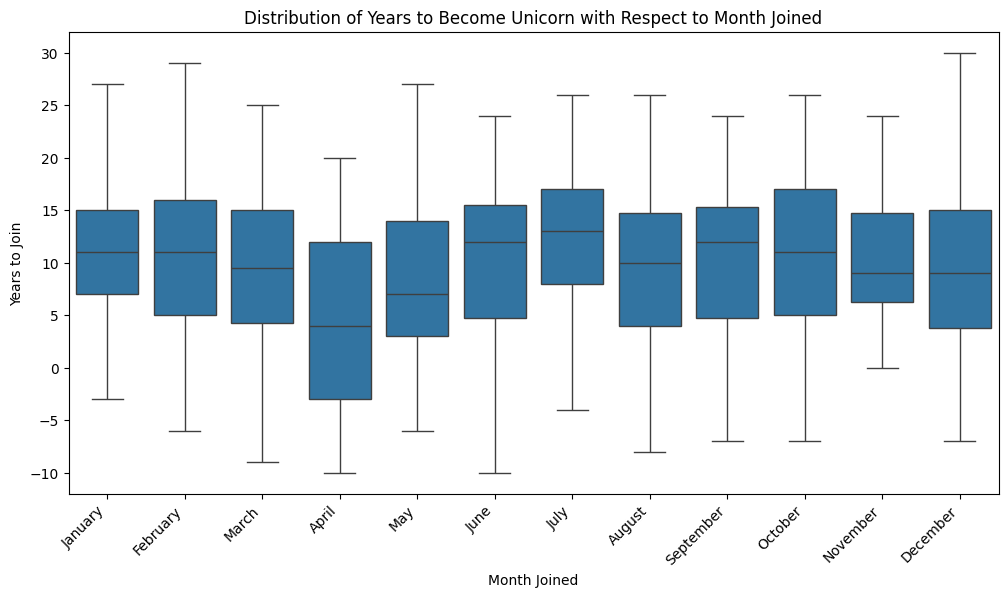

In [10]:
plt.figure(figsize=(12, 6))

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

sns.boxplot(
    x=companies['Month Joined'],
    y=companies['Years To Join'],
    order=month_order,
    showfliers=False
)

plt.title('Distribution of Years to Become Unicorn with Respect to Month Joined')
plt.xlabel('Month Joined')
plt.ylabel('Years to Join')
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

Step 4 — Visualizing Average Years to Become Unicorn by Founding Year

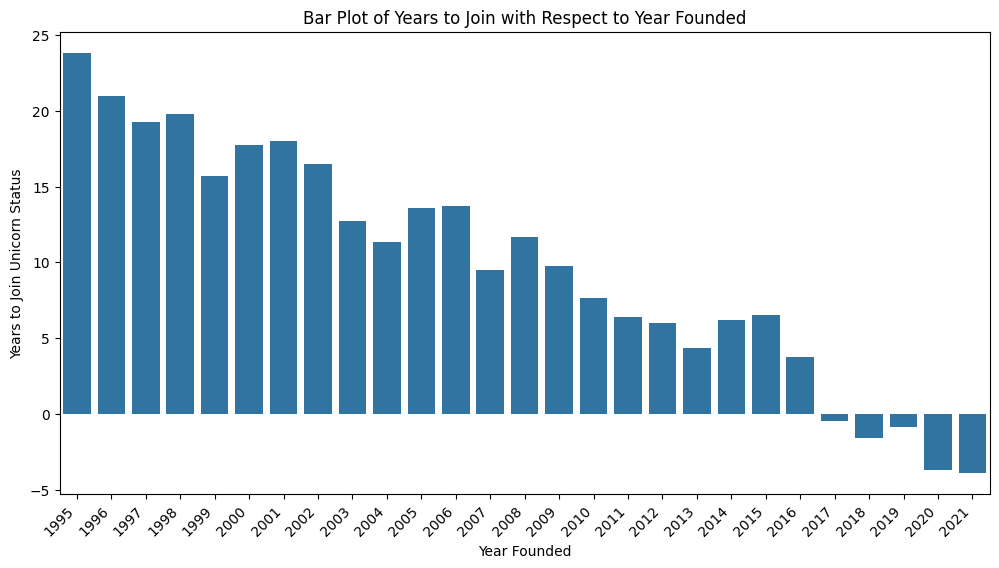

In [11]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=companies["Year Founded"],
    y=companies["Years To Join"],
    errorbar=None  # Standard syntax replacing deprecated ci=False
)

plt.title("Bar Plot of Years to Join with Respect to Year Founded")
plt.xlabel("Year Founded")
plt.ylabel("Years to Join Unicorn Status")
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

Visualizing Weekly Joins in 2021

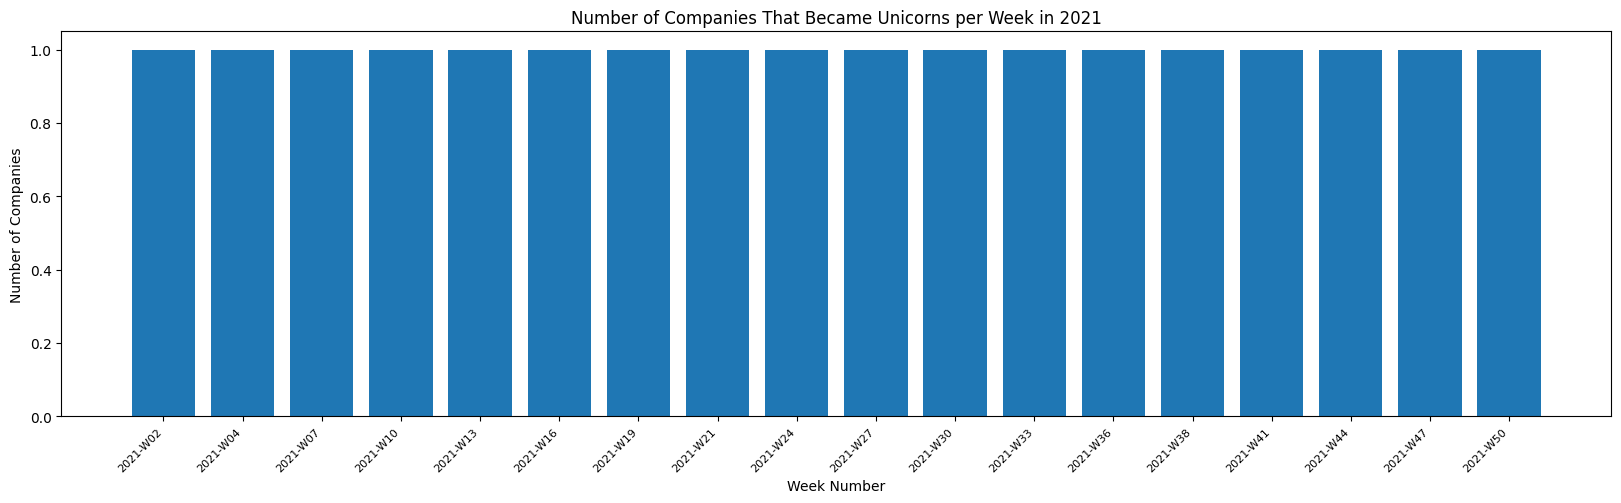

In [12]:
plt.figure(figsize=(20, 5))

plt.bar(
    x=companies_by_week_2021['Week Joined'],
    height=companies_by_week_2021['Company Count']
)

plt.xlabel("Week Number")
plt.ylabel("Number of Companies")
plt.title("Number of Companies That Became Unicorns per Week in 2021")
plt.xticks(rotation=45, horizontalalignment='right', fontsize=8)
plt.show()

Visualizing Quarterly Average Valuations (2020 vs 2021 Grouped Bar Chart)

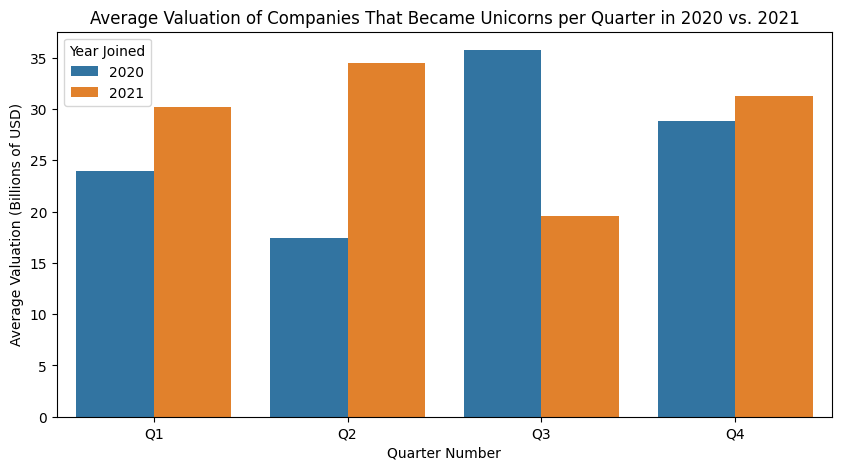

In [13]:
# Helper columns for grouped bar chart
companies_by_quarter_2020_2021['Quarter Number'] = companies_by_quarter_2020_2021['Quarter Joined'].str[-2:]
companies_by_quarter_2020_2021['Year Joined'] = companies_by_quarter_2020_2021['Quarter Joined'].str[:4]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=companies_by_quarter_2020_2021['Quarter Number'],
    y=companies_by_quarter_2020_2021['Average Valuation'],
    hue=companies_by_quarter_2020_2021['Year Joined']
)

plt.xlabel("Quarter Number")
plt.ylabel("Average Valuation (Billions of USD)")
plt.title("Average Valuation of Companies That Became Unicorns per Quarter in 2020 vs. 2021")
plt.show()